<a href="https://colab.research.google.com/github/Aishwaryaselvaraju/CODSOFT/blob/main/Codsoft_Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project:** Movie Rating Prediction using Machine Learning

**Dataset Source:** IMDb / TMDb / Kaggle Movie Metadata Dataset

**Description:** This project aims to predict the rating of a movie based on features such as genre, director, actors, runtime, language, and country. By analyzing historical movie data, the model estimates user or critic ratings using regression techniques, helping to uncover key factors that influence movie ratings.

**Tools Used:** Python, Pandas, NumPy, Seaborn, Matplotlib, Scikit-Learn, Random Forest Regressor, Label Encoding

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving IMDb.csv to IMDb.csv


In [ ]:
df = pd.read_csv('IMDb.csv', encoding='ISO-8859-1')
print(df.head())

                                 Name    Year Duration            Genre  \
0                                         NaN      NaN            Drama   
1  #Gadhvi (He thought he was Gandhi)  (2019)  109 min            Drama   
2                         #Homecoming  (2021)   90 min   Drama, Musical   
3                             #Yaaram  (2019)  110 min  Comedy, Romance   
4                   ...And Once Again  (2010)  105 min            Drama   

   Rating Votes            Director       Actor 1             Actor 2  \
0     NaN   NaN       J.S. Randhawa      Manmauji              Birbal   
1     7.0     8       Gaurav Bakshi  Rasika Dugal      Vivek Ghamande   
2     NaN   NaN  Soumyajit Majumdar  Sayani Gupta   Plabita Borthakur   
3     4.4    35          Ovais Khan       Prateik          Ishita Raj   
4     NaN   NaN        Amol Palekar  Rajat Kapoor  Rituparna Sengupta   

           Actor 3  
0  Rajendra Bhatia  
1    Arvind Jangid  
2       Roy Angana  
3  Siddhant Kapoor  
4    

In [ ]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB
None
Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64


In [ ]:
print(df.columns.tolist())

['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']


In [ ]:
# Drop rows with missing target values
df = df.dropna(subset=['Rating'])

# Select and rename useful features
df = df[['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3', 'Duration', 'Rating']]

# Fill missing values
df.fillna('Unknown', inplace=True)

# Rename columns for consistency
df.rename(columns={
    'Actor 1': 'Actor1',
    'Actor 2': 'Actor2',
    'Actor 3': 'Actor3',
    'Duration': 'Runtime'
}, inplace=True)

# Convert Runtime to numeric if needed
df['Runtime'] = df['Runtime'].astype(str).str.extract('(\d+)')
df['Runtime'] = pd.to_numeric(df['Runtime'], errors='coerce')

In [ ]:

# Encode only the available categorical features
for col in ['Genre', 'Director', 'Actor1', 'Actor2', 'Actor3']:
    df[col] = df[col].astype(str)
    df[col] = LabelEncoder().fit_transform(df[col])

In [ ]:
X = df.drop('Rating', axis=1)
y = df['Rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")

Mean Squared Error: 1.6364238559641553
R² Score: 0.11979768540362956


In [ ]:
new_movie = pd.DataFrame({
    'Genre': [12],        # Make sure 12 corresponds to a valid encoded genre
    'Director': [4],      # Encoded value
    'Actor1': [45],       # Encoded actor ID
    'Actor2': [78],
    'Actor3': [102],
    'Runtime': [120]
})

# Predict
predicted_rating = model.predict(new_movie)
print("Predicted Rating:", predicted_rating[0])

Predicted Rating: 5.643


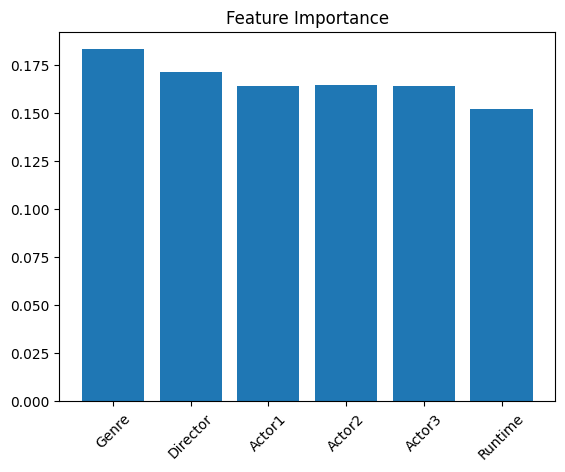

In [ ]:

importance = model.feature_importances_
plt.bar(X.columns, importance)
plt.title('Feature Importance')
plt.xticks(rotation=45)
plt.show()

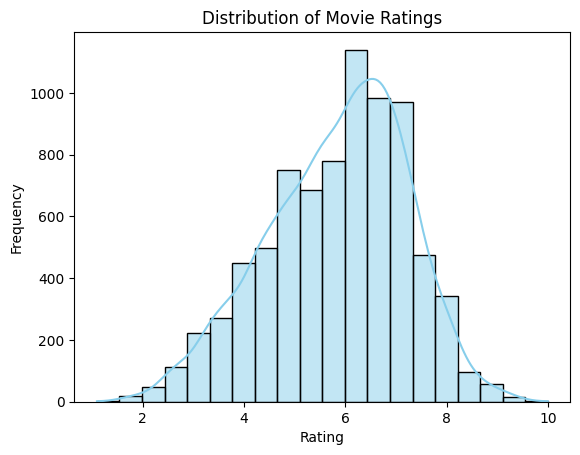

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Rating'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()


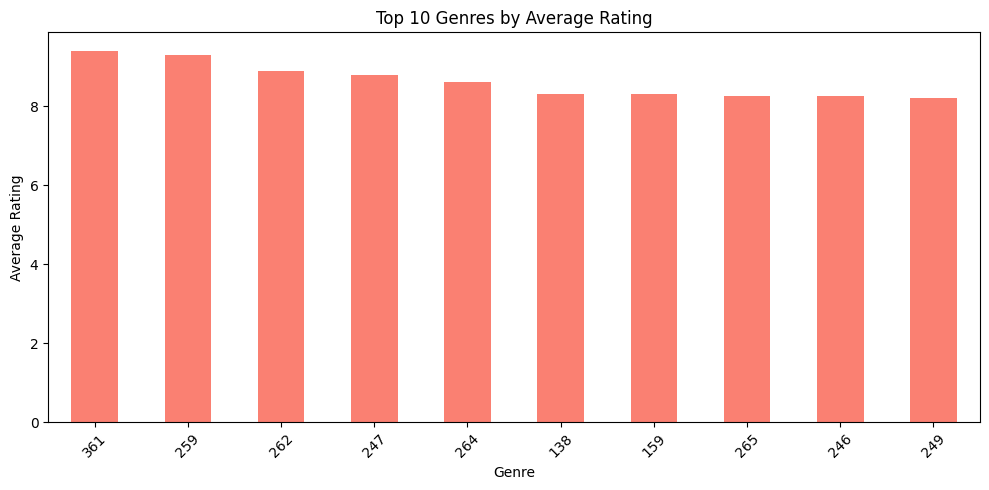

In [ ]:
genre_avg = df.groupby('Genre')['Rating'].mean().sort_values(ascending=False).head(10)


plt.figure(figsize=(10, 5))
genre_avg.plot(kind='bar', color='salmon')
plt.title('Top 10 Genres by Average Rating')
plt.ylabel('Average Rating')
plt.xlabel('Genre')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

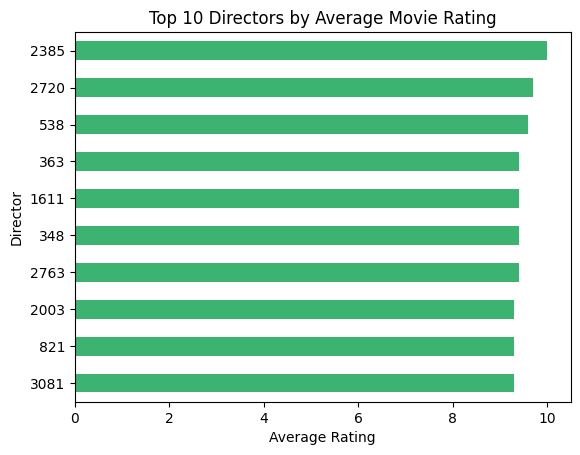

In [ ]:
top_directors = df.groupby('Director')['Rating'].mean().sort_values(ascending=False).head(10)
top_directors.plot(kind='barh', color='mediumseagreen')
plt.title('Top 10 Directors by Average Movie Rating')
plt.xlabel('Average Rating')
plt.gca().invert_yaxis()
plt.show()

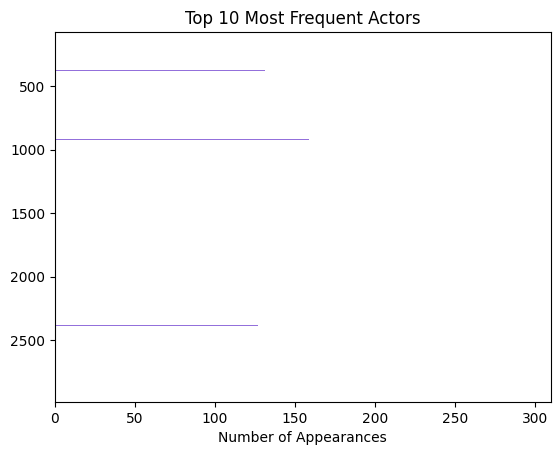

In [ ]:
from collections import Counter

actors = df['Actor1'].tolist() + df['Actor2'].tolist() + df['Actor3'].tolist()
actor_counts = Counter(actors)
top_actors = dict(Counter(actor_counts).most_common(10))

plt.barh(list(top_actors.keys()), list(top_actors.values()), color='mediumpurple')
plt.xlabel('Number of Appearances')
plt.title('Top 10 Most Frequent Actors')
plt.gca().invert_yaxis()
plt.show()


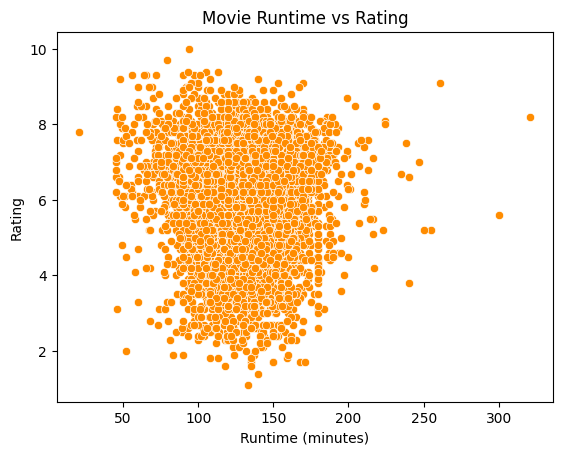

In [ ]:
sns.scatterplot(data=df, x='Runtime', y='Rating', color='darkorange')
plt.title('Movie Runtime vs Rating')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Rating')
plt.show()


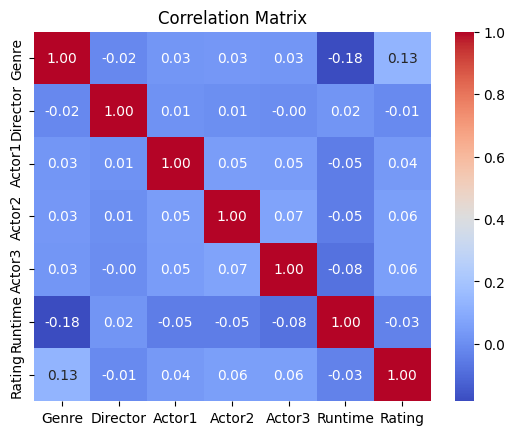

In [ ]:
import numpy as np

corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

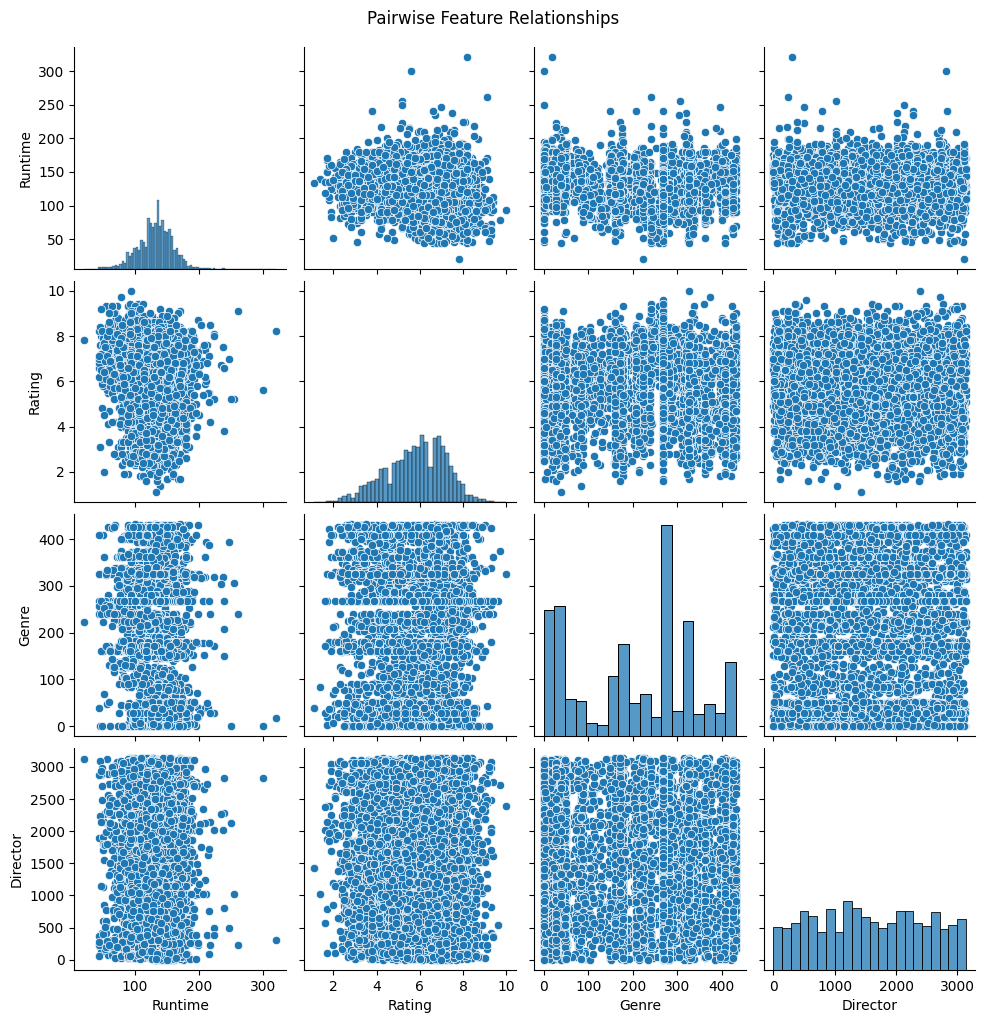

In [ ]:
sns.pairplot(df[['Runtime', 'Rating', 'Genre', 'Director']])
plt.suptitle('Pairwise Feature Relationships', y=1.02)
plt.show()